In [12]:
# here we are simulating the 2nd way to create subgraphs in LangGraph

# in this we directly add subgraph with nodes (shared state)

In [13]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [14]:
load_dotenv()

True

In [15]:
LLM = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [16]:
# state - for all
class TranslateState(TypedDict):
    question: str
    eng_ans: str
    hin_ans: str

In [17]:
# subgraph

In [18]:
def translate_node(state:TranslateState):

    prompt = f"""
    You are a helpful assistent

    Translate the following text in hindi.
    keep it natural and clear, don't add extra content

    Text : {state["eng_ans"]}
"""
    translation = LLM.invoke(prompt).content

    return {"hin_ans":translation}

In [19]:
subgraph_builder = StateGraph(TranslateState)

subgraph_builder.add_node("translate_node",translate_node)

subgraph_builder.add_edge(START,"translate_node")
subgraph_builder.add_edge("translate_node",END)

subgraph = subgraph_builder.compile()

In [20]:
# main graph

In [21]:
def answer_node(state:TranslateState):

    prompt = f"""
    You are a helpful assistant

    answer the following question:

    Question: {state['question']}
"""

    answer = LLM.invoke(prompt).content

    return {"eng_ans":answer}

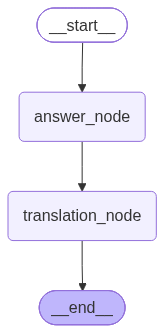

In [22]:
graph_builder = StateGraph(TranslateState)

graph_builder.add_node("answer_node", answer_node)
graph_builder.add_node("translation_node",subgraph)

graph_builder.add_edge(START,"answer_node")
graph_builder.add_edge("answer_node","translation_node")
graph_builder.add_edge("translation_node",END)

graph = graph_builder.compile()

graph

In [23]:
graph.invoke({"question":"who is the president of india?"})

{'question': 'who is the president of india?',
 'eng_ans': 'The President of India is Droupadi Murmu. She took office on July 25, 2022, and is the 15th President of India. Prior to her presidency, she served as the Governor of Jharkhand from 2015 to 2021.',
 'hin_ans': 'भारत की राष्ट्रपति द्रौपदी मुर्मू हैं। उन्होंने 25 जुलाई, 2022 को पदभार संभाला और वे भारत की 15वीं राष्ट्रपति हैं। राष्ट्रपति बनने से पहले, उन्होंने 2015 से 2021 तक झारखंड की राज्यपाल के रूप में कार्य किया।'}